# Visualizing Model Innovations

This notebook visualizes the key innovations in our new model, including feature engineering, data cleaning, and feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor

## 1. Load Data and Feature Engineering

In [2]:
file_path = 'california_housing.csv'
housing_df = pd.read_csv(file_path)

# Feature Engineering: Create bed_to_room_ratio
housing_df['bed_to_room_ratio'] = housing_df['AveBedrms'] / housing_df['AveRooms']
housing_df.replace([np.inf, -np.inf], np.nan, inplace=True)
housing_df.dropna(inplace=True)

## 2. Visualize Engineered Feature: Bedroom-to-Room Ratio

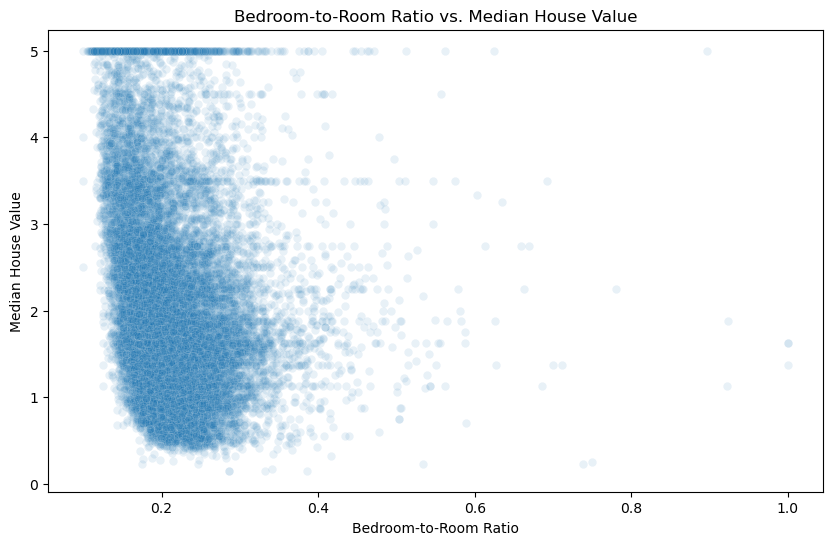

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bed_to_room_ratio', y='MedHouseVal', data=housing_df, alpha=0.1)
plt.title('Bedroom-to-Room Ratio vs. Median House Value')
plt.xlabel('Bedroom-to-Room Ratio')
plt.ylabel('Median House Value')
plt.show()

## 3. Data Cleaning: Outlier Removal

### Average Occupancy: Before and After

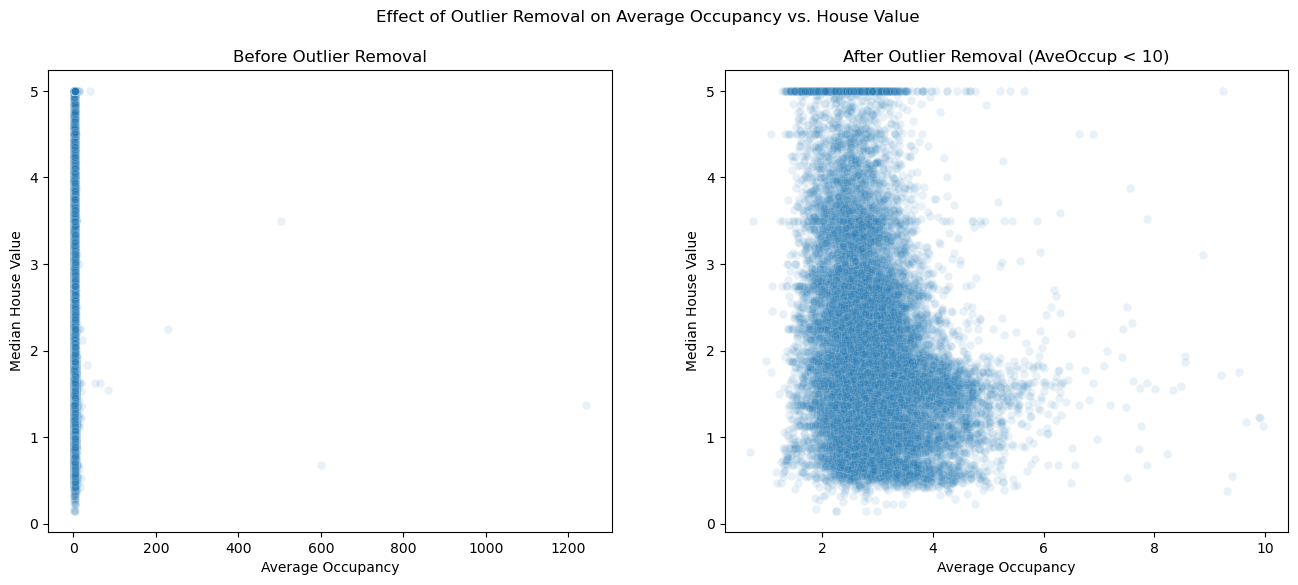

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before outlier removal
sns.scatterplot(ax=axes[0], x='AveOccup', y='MedHouseVal', data=housing_df, alpha=0.1)
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Average Occupancy')
axes[0].set_ylabel('Median House Value')

# After outlier removal
housing_df_filtered = housing_df[housing_df['AveOccup'] < 10]
sns.scatterplot(ax=axes[1], x='AveOccup', y='MedHouseVal', data=housing_df_filtered, alpha=0.1)
axes[1].set_title('After Outlier Removal (AveOccup < 10)')
axes[1].set_xlabel('Average Occupancy')
axes[1].set_ylabel('Median House Value')

plt.suptitle('Effect of Outlier Removal on Average Occupancy vs. House Value')
plt.show()

### Average Rooms: Before and After

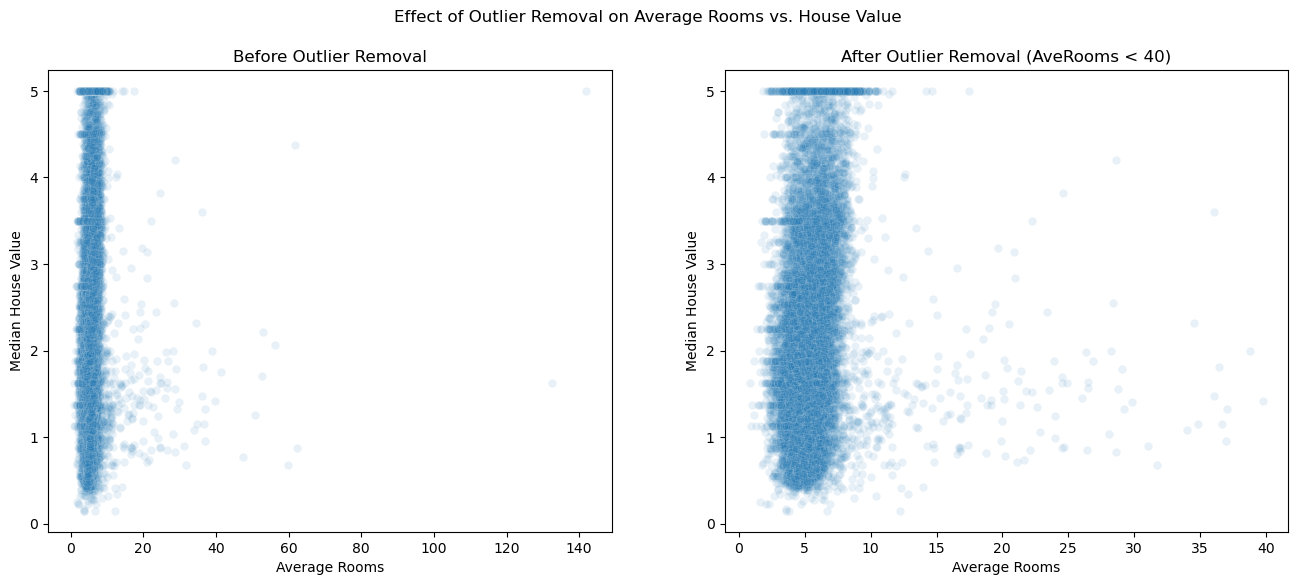

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before outlier removal
sns.scatterplot(ax=axes[0], x='AveRooms', y='MedHouseVal', data=housing_df, alpha=0.1)
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Average Rooms')
axes[0].set_ylabel('Median House Value')

# After outlier removal
housing_df_filtered_rooms = housing_df[housing_df['AveRooms'] < 40]
sns.scatterplot(ax=axes[1], x='AveRooms', y='MedHouseVal', data=housing_df_filtered_rooms, alpha=0.1)
axes[1].set_title('After Outlier Removal (AveRooms < 40)')
axes[1].set_xlabel('Average Rooms')
axes[1].set_ylabel('Median House Value')

plt.suptitle('Effect of Outlier Removal on Average Rooms vs. House Value')
plt.show()

## 4. Feature Importance

/var/folders/xy/ttdr2xm51vl2fz7sfktlbq1w0000gn/T/ipykernel_9692/2575527641.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')


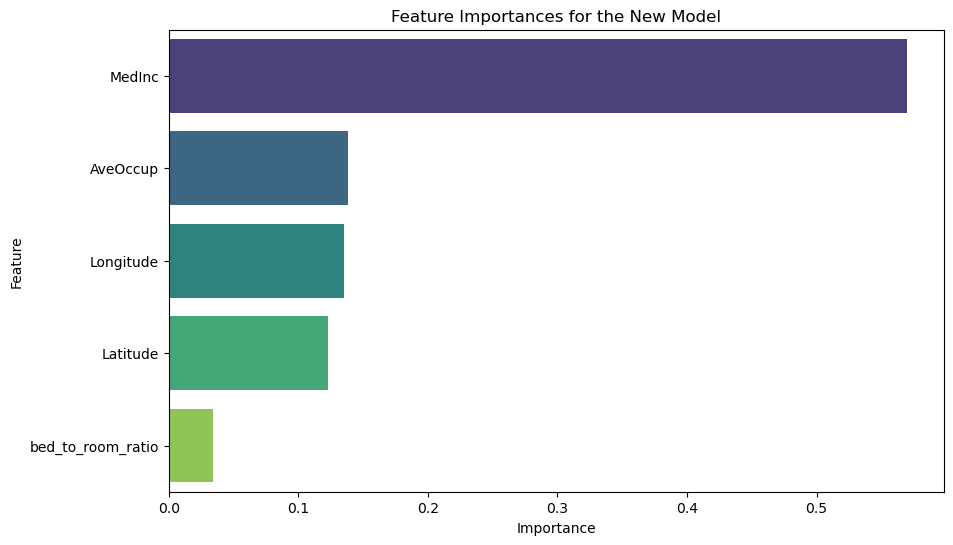

In [6]:
# Prepare data for the model
housing_df_cleaned = housing_df[(housing_df['AveOccup'] < 10) & (housing_df['AveRooms'] < 40)]
features = ['Latitude', 'Longitude', 'MedInc', 'AveOccup', 'bed_to_room_ratio']
X = housing_df_cleaned[features]
y = housing_df_cleaned['MedHouseVal']

# Train the model
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gbr.fit(X, y)

# Get feature importances
feature_importances = pd.DataFrame({'feature': features, 'importance': gbr.feature_importances_})
feature_importances = feature_importances.sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')
plt.title('Feature Importances for the New Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()